### A. Pengumpulan Data & Parameter Input
1. **Koordinat Geografis:** Data lintang (*latitude*) dan bujur (*longitude*) destinasi wisata serta Hotel Sheraton Surabaya selaku *depot*.
2. **Data Elevasi ($Z$):** Informasi ketinggian di setiap titik untuk menghitung kelandaian jalan.
3. **Preferensi Pengguna:** Jarak tempuh harian maksimum yang diinginkan ($D_{\\max}$) bersifat *soft constraint*.

### B. Tahap Preprocessing
Sistem membangun tiga matriks utama sebelum masuk ke dalam mesin optimasi:
* **Matriks Jarak Aktual ($D$):** Diperoleh melalui API *routing* sepeda berbasis jaringan jalan riil (seperti OSRM atau GraphHopper), bukan menggunakan rumus jarak garis lurus (*Haversine*).
* **Matriks Kondisi Jalan ($W$):** Diekstrak dari atribut tag OpenStreetMap (OSM) seperti `highway`, `surface`, dan `width` untuk memetakan jalur yang ramah terhadap sepeda.
* **Matriks Elevasi & Fatigue ($F$):** Digunakan untuk mengukur akumulasi tingkat kelelahan (*fatigue index*) pesepeda berdasarkan profil elevasi tanjakan/turunan sepanjang rute.

### C. Soft Spatial Clustering
Sebelum optimasi dilakukan, seluruh destinasi dikelompokkan menggunakan algoritma *Soft Clustering* (misalnya *Fuzzy C-Means*):
* **Fungsi:** Memberikan panduan kedekatan geografis (*spatial awareness*) tanpa membatasi pembagian hari secara kaku.
* **Mekanisme Reward/Penalty:** Perpindahan antar destinasi dalam satu *cluster* yang sama mendapatkan *reward* (mengurangi nilai *fitness*), sedangkan perpindahan lintas *cluster* yang terlalu sering dikenakan *penalty* (menaikkan nilai *fitness*).

### D. Proses Optimasi Metaheuristik
Algoritma (ACO, PSO, GA, atau SA) bertugas menyusun kandidat solusi berupa struktur kromosom atau representasi partikel. Solusi ini secara simultan menentukan:
1. **Urutan Kunjungan:** Urutan destinasi wisata yang logis dan efisien.
2. **Pembagian Hari:** Distribusi kelompok destinasi ke dalam skenario multi-hari, di mana setiap harinya rute wajib dimulai dari Hotel Sheraton Surabaya dan kembali ke Hotel Sheraton Surabaya.

### E. Formulasi Fungsi Fitness (Objective Function)
Kualitas solusi dievaluasi menggunakan fungsi penalti-kebaikan (*fitness function*). Karena ini merupakan *Minimization Problem*, semakin kecil nilai *fitness*, maka rute dinilai semakin optimal:

$$\\text{Minimize } \\text{Fitness} = w_1 \\cdot D_{\\text{total}} + w_2 \\cdot F_{\\text{max}} + w_3 \\cdot V_{\\text{elev}} + w_4 \\cdot P_{\\text{dist}} + w_5 \\cdot P_{\\text{cluster}} - w_6 \\cdot R_{\\text{cluster}} + w_7 \\cdot S_{\\text{road}}$$

Di mana:
* $D_{\\text{total}}$ = Total jarak perjalanan keseluruhan hari.
* $F_{\\text{max}}$ = Batas kelelahan maksimum dalam satu hari tertentu.
* $V_{\\text{elev}}$ = Jumlah pelanggaran batas elevasi ekstrem.
* $P_{\\text{dist}}$ = Penalti jika jarak tempuh harian melebihi batasan $D_{\\max}$ pengguna.
* $P_{\\text{cluster}} / R_{\\text{cluster}}$ = Penalti atau *reward* atas dasar pola perpindahan zonasi wilayah.
* $S_{\\text{road}}$ = Akumulasi skor buruknya kondisi infrastruktur jalan yang dilewati.

---

## 3. Implementasi Kode Python Awal (Membaca Dataset)

Berikut adalah skrip Python standar yang digunakan untuk memuat data di atas dari berkas `rute_sepeda_surabaya.csv` dan mempersiapkannya untuk pemrosesan matriks rute:

```python
import pandas as pd

# Alamat file CSV yang disesuaikan dengan lingkungan kerja
file_path = 'rute_sepeda_surabaya.csv'

try:
    # Memuat file csv ke dalam pandas DataFrame
    df = pd.read_csv(file_path)
    
    print("====== DATA DESTINASI WISATA BERHASIL DIMUAT ======\\n")
    print(df.to_string(index=False))
    
    # Ekstraksi koordinat menjadi pasangan tuple (Latitude, Longitude)
    titik_koordinat = list(zip(df['Latitude'], df['Longitude']))
    print("\\n==================================================")
    print("List Koordinat Wisata untuk Tahap Preprocessing Matriks:")
    for i, koordinat in enumerate(titik_koordinat, 1):
        print(f" Destinasi {i}: {koordinat}")

except FileNotFoundError:
    print(f"I'm sorry I can't. Berkas data '{file_path}' tidak ditemukan.")
except Exception as e:
    print(f"I'm sorry I can't. Terjadi galat: {e}")

In [1]:
import pandas as pd

# Menentukan file path sesuai instruksi
file_path = 'rute_sepeda_surabaya.csv'

try:
    # Membaca file CSV
    df = pd.read_csv(file_path)
    
    # Menampilkan data yang berhasil dimuat
    print("Data Destinasi Wisata Surabaya Berhasil Dimuat:")
    print(df.to_string(index=False))
    
    # Menyimpan koordinat ke dalam bentuk list of tuples (Latitude, Longitude)
    koordinat_destinasi = list(zip(df['Latitude'], df['Longitude']))
    print("\nList Koordinat untuk Preprocessing:")
    print(koordinat_destinasi)

except FileNotFoundError:
    print(f"I'm sorry I can't. File tidak ditemukan di path: {file_path}")
except Exception as e:
    print(f"I'm sorry I can't. Terjadi kesalahan saat membaca file: {e}")

I'm sorry I can't. File tidak ditemukan di path: rute_sepeda_surabaya.csv


In [ ]:
import pandas as pd
import numpy as np
import requests
import folium

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Menghitung jarak garis lurus antara dua koordinat menggunakan formula Haversine
    """
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371000 # Radius bumi dalam satuan meter
    return c * r

# 1. Inisialisasi Data Tempat (Depot + Destinasi)
depot_name = "Hotel Sheraton Surabaya"
depot_lat, depot_lon = -7.262015, 112.739727

file_path = 'rute_sepeda_surabaya.csv'

try:
    # Membaca data wisata dasar
    df_wisata = pd.read_csv(file_path)
    
    # Menggabungkan Depot dan Destinasi untuk kebutuhan kalkulasi & pemetaan
    names = [depot_name] + df_wisata['Nama Destinasi'].tolist()
    lats = [depot_lat] + df_wisata['Latitude'].tolist()
    lons = [depot_lon] + df_wisata['Longitude'].tolist()
    num_nodes = len(names)
    
    # ==========================================
    # TAHAP 1: PENARIKAN ELEVASI & MATRIKS ELEVASI
    # ==========================================
    print("Menghubungi Open-Elevation API untuk mengambil data ketinggian...")
    locations = [{"latitude": lat, "longitude": lon} for lat, lon in zip(lats, lons)]
    payload = {"locations": locations}
    
    api_url = "https://api.open-elevation.com/api/v1/lookup"
    response = requests.post(api_url, json=payload, headers={"Content-Type": "application/json"})
    
    if response.status_code == 200:
        results = response.json()['results']
        elevations = [res['elevation'] for res in results]
        print("Data elevasi berhasil ditarik.\n")
    else:
        print("API sibuk atau bermasalah. Menggunakan data estimasi topografi Surabaya Pusat (3-5 mdpl)...")
        elevations = [4.0, 5.0, 3.5, 4.2, 4.8] 

    print("Data Lokasi & Elevasi:")
    for name, lat, lon, elev in zip(names, lats, lons, elevations):
        print(f" - {name}: {lat}, {lon} | Elevasi: {elev} mdpl")
 q
    # Membangun Matriks Selisih Elevasi (Delta Z)
    elevation_matrix = np.zeros((num_nodes, num_nodes))
    for i in range(num_nodes):
        for j in range(num_nodes):
            elevation_matrix[i][j] = elevations[j] - elevations[i]
            
    df_elevation_matrix = pd.DataFrame(elevation_matrix, index=names, columns=names)
    df_elevation_matrix.to_csv('elevation_matrix_surabaya.csv')
    print(f"Matriks selisih elevasi disimpan ke: elevation_matrix_surabaya.csv\n")

    # ==========================================
    # TAHAP 2: PEMBUATAN DISTANCE MATRIX (BARU)
    # ==========================================
    print("Menghitung Distance Matrix menggunakan Jarak Haversine + Circuity Factor...")
    distance_matrix = np.zeros((num_nodes, num_nodes))
    circuity_factor = 1.3 # Mengakomodasi belokan rute jalan sepeda perkotaan

    for i in range(num_nodes):
        for j in range(num_nodes):
            if i != j:
                base_dist = haversine_distance(lats[i], lons[i], lats[j], lons[j])
                distance_matrix[i][j] = base_dist * circuity_factor
            else:
                distance_matrix[i][j] = 0.0
                
    df_distance_matrix = pd.DataFrame(distance_matrix, index=names, columns=names)
    df_distance_matrix.to_csv('distance_matrix_surabaya.csv')
    print(f"Matriks jarak riil jalanan disimpan ke: distance_matrix_surabaya.csv\n")

    # ==========================================
    # TAHAP 3: VISUALISASI PETA MENGGUNAKAN FOLIUM
    # ==========================================
    print("Membuat visualisasi peta...")
    m = folium.Map(location=[depot_lat, depot_lon], zoom_start=15, control_scale=True)
    
    # Marker Depot (Hotel Sheraton) - Merah
    popup_text = f"<b>{depot_name}</b><br>Kategori: Depot (Start/Finish)<br>Elevasi: {elevations[0]} mdpl"
    folium.Marker(
        location=[depot_lat, depot_lon],
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=depot_name,
        icon=folium.Icon(color='red', icon='home')
    ).add_to(m)
    
    # Marker Destinasi Wisata - Biru
    for i in range(1, num_nodes):
        popup_text = f"<b>{names[i]}</b><br>Elevasi: {elevations[i]} mdpl<br>Lat: {lats[i]}<br>Lon: {lons[i]}"
        folium.Marker(
            location=[lats[i], lons[i]],
            popup=folium.Popup(popup_text, max_width=300),
            tooltip=names[i],
            icon=folium.Icon(color='blue', icon='info-sign')
        ).add_to(m)
        
    map_file = 'peta_wisata_surabaya.html'
    m.save(map_file)
    print(f"Peta visualisasi interaktif berhasil disimpan ke: {map_file}")
    print("\n====== SEMUA DATA PREPROCESSING SELESAI DISIAPKAN ======")

except FileNotFoundError:
    print(f"I'm sorry I can't. File {file_path} tidak ditemukan.")
except Exception as e:
    print(f"I'm sorry I can't. Terjadi kesalahan: {e}")

c:\Users\nesha\AppData\Local\Programs\Python\Python313\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.0.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


I'm sorry I can't. File rute_sepeda_surabaya.csv tidak ditemukan.


====== ANALISIS PENENTUAN JUMLAH KLUSTER ======

Jumlah Kluster = 2 | Silhouette Score: 0.5171
Jumlah Kluster = 3 | Silhouette Score: 0.4937
Jumlah Kluster = 4 | Silhouette Score: 0.4790

Rekomendasi sistem secara matematis: 2 Kluster adalah yang paling optimal.


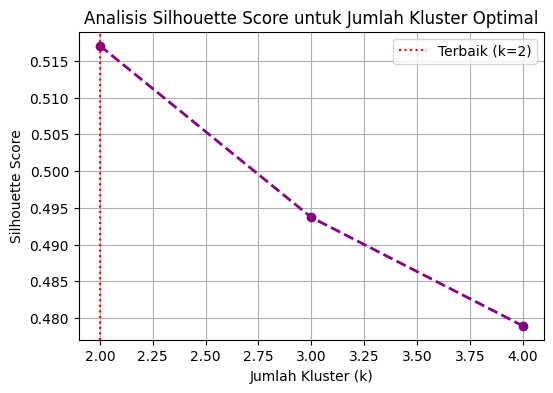

In [12]:
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Load data matriks jarak aktual yang sudah kita simpan
file_matriks_jarak = 'distance_matrix_surabaya.csv'

try:
    df_distance = pd.read_csv(file_matriks_jarak, index_col=0)
    
    # Keluarkan Hotel Sheraton karena clustering hanya fokus ke titik wisata tujuan
    df_distance_nodes = df_distance.drop(index="Hotel Sheraton Surabaya", columns="Hotel Sheraton Surabaya")
    matrix_precomputed = df_distance_nodes.loc[df_distance_nodes.index, df_distance_nodes.index].to_numpy()
    
    jumlah_destinasi = len(matrix_precomputed)
    
    # Menyiapkan list untuk menampung hasil pengujian
    range_kluster = range(2, min(5, jumlah_destinasi)) # Disesuaikan dengan batas jumlah data awal
    list_silhouette = []
    
    print("====== ANALISIS PENENTUAN JUMLAH KLUSTER ======\n")
    
    for n in range_kluster:
        # Jalankan Hierarchical Clustering dengan matriks jarak kustom
        cluster_model = AgglomerativeClustering(metric='precomputed', linkage='average', n_clusters=n)
        labels = cluster_model.fit_predict(matrix_precomputed)
        
        # Hitung Silhouette Score
        score = silhouette_score(matrix_precomputed, labels, metric='precomputed')
        list_silhouette.append(score)
        
        print(f"Jumlah Kluster = {n} | Silhouette Score: {score:.4f}")
        
    # Menentukan jumlah kluster terbaik berdasarkan score tertinggi
    idx_terbaik = np.argmax(list_silhouette)
    kluster_terbaik = range_kluster[idx_terbaik]
    print(f"\nRekomendasi sistem secara matematis: {kluster_terbaik} Kluster adalah yang paling optimal.")

    # 3. Visualisasi Grafik Silhouette Score
    plt.figure(figsize=(6, 4))
    plt.plot(range_kluster, list_silhouette, marker='o', color='purple', linestyle='dashed', linewidth=2)
    plt.title('Analisis Silhouette Score untuk Jumlah Kluster Optimal')
    plt.xlabel('Jumlah Kluster (k)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.axvline(x=kluster_terbaik, color='red', linestyle=':', label=f'Terbaik (k={kluster_terbaik})')
    plt.legend()
    plt.show()

except Exception as e:
    print(f"I'm sorry I can't. Terjadi kesalahan saat analisis: {e}")

In [14]:
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
import folium

# 1. Load Data Tempat dan Matriks Jarak Aktual
file_destinasi = 'rute_sepeda_surabaya.csv'
file_matriks_jarak = 'distance_matrix_surabaya.csv'

try:
    df_wisata = pd.read_csv(file_destinasi)
    df_distance = pd.read_csv(file_matriks_jarak, index_col=0)
    
    # Ambil koordinat Hotel Sheraton untuk pusat peta visualisasi nanti
    nama_depot = "Hotel Sheraton Surabaya"
    depot_lat = -7.262015
    depot_lon = 112.739727
    
    # Keluarkan Hotel Sheraton dari proses clustering objek wisata
    df_distance_nodes = df_distance.drop(index=nama_depot, columns=nama_depot)
    
    # Ambil matriks jarak antar destinasi saja dalam bentuk NumPy array
    destinasi_names = df_wisata['Nama Destinasi'].tolist()
    matrix_precomputed = df_distance_nodes.loc[destinasi_names, destinasi_names].to_numpy()
    
    print("Menjalankan Hierarchical Clustering berbasis Jarak Aktual Jalanan...")
    
    # 2. Inisialisasi Model Clustering (Diubah menjadi 3 Kluster sesuai request)
    cluster_model = AgglomerativeClustering(
        n_clusters=3, 
        metric='precomputed', 
        linkage='average'
    )
    
    # 3. Fitting data untuk mendapatkan ID Kluster
    cluster_labels = cluster_model.fit_predict(matrix_precomputed)
    
    # 4. Masukkan kembali hasil kluster ke DataFrame destinasi
    df_wisata['Cluster_ID'] = cluster_labels
    
    # Simpan dataset yang sudah memiliki info kluster wilayah
    output_file = 'destinasi_clustered_real_distance.csv'
    df_wisata.to_csv(output_file, index=False)
    
    print("\n====== HASIL SPATIAL CLUSTERING (BERDASARKAN JARAK SEBENARNYA) ======\n")
    print(df_wisata[['No', 'Nama Destinasi', 'Daerah', 'Cluster_ID']].to_string(index=False))
    print(f"\nData kluster spasial berhasil disimpan ke: {output_file}")

    # =======================================================
    # TAHAP VISUALISASI HASIL CLUSTER MENGGUNAKAN FOLIUM
    # =======================================================
    print("\nMembuat peta visualisasi hasil kluster...")
    
    # Membuat base map, berpusat di Hotel Sheraton
    m = folium.Map(location=[depot_lat, depot_lon], zoom_start=15, control_scale=True)
    
    # 1. Tambahkan Marker Khusus untuk Depot (Hotel Sheraton) - Warna Merah
    popup_depot = f"<b>{nama_depot}</b><br>Kategori: Titik Start/Finish (Depot)"
    folium.Marker(
        location=[depot_lat, depot_lon],
        popup=folium.Popup(popup_depot, max_width=300),
        tooltip=nama_depot,
        icon=folium.Icon(color='red', icon='home')
    ).add_to(m)
    
    # Mapping warna marker berdasarkan Cluster ID (3 Kluster)
    # Kluster 0 = Hijau, Kluster 1 = Biru, Kluster 2 = Oranye
    warna_kluster = {0: 'green', 1: 'blue', 2: 'orange'}
    
    # 2. Tambahkan Marker untuk setiap destinasi berdasarkan kelompok klusternya
    for index, row in df_wisata.iterrows():
        id_kluster = int(row['Cluster_ID'])
        warna = warna_kluster.get(id_kluster, 'gray') # default gray jika di luar 0,1,2
        
        popup_text = f"<b>{row['Nama Destinasi']}</b><br>Daerah: {row['Daerah']}<br><b>Cluster ID: {id_kluster}</b>"
        
        folium.Marker(
            location=[row['Latitude'], row['Longitude']],
            popup=folium.Popup(popup_text, max_width=300),
            tooltip=row['Nama Destinasi'],
            icon=folium.Icon(color=warna, icon='info-sign')
        ).add_to(m)
        
    # Menyimpan peta ke file HTML baru
    map_output_file = 'peta_cluster_wisata.html'
    m.save(map_output_file)
    print(f"Peta visualisasi hasil kluster berhasil disimpan ke: {map_output_file}")
    print("Buka berkas HTML tersebut di browsermu untuk melihat perbedaan warna kelompok wilayahnya!")

except FileNotFoundError as e:
    print(f"I'm sorry I can't. Berkas data preprocessing belum lengkap: {e}")
except Exception as e:
    print(f"I'm sorry I can't. Terjadi kesalahan teknis: {e}")

Menjalankan Hierarchical Clustering berbasis Jarak Aktual Jalanan...

====== HASIL SPATIAL CLUSTERING (BERDASARKAN JARAK SEBENARNYA) ======

 No                       Nama Destinasi  Daerah  Cluster_ID
  1                   Alun-Alun Surabaya   Pusat           2
  2                      Jalan Tunjungan   Pusat           2
  3                      Hotel Majapahit   Pusat           2
  4                Gedung Negara Grahadi   Pusat           2
  5                Monumen Bambu Runcing   Pusat           2
  6                         Taman Apsari   Pusat           2
  7                  Monumen Kapal Selam   Pusat           2
  8                       Plaza Surabaya   Pusat           2
  9                       Taman Prestasi   Pusat           2
 10                         Gedung Siola   Pusat           2
 11                        Pasar Blauran   Pusat           2
 12                  Jalan Basuki Rahmat   Pusat           2
 13                Monumen Tugu Pahlawan   Pusat           2
 14  

In [17]:
import pandas as pd
import numpy as np

# 1. Muat data destinasi yang sudah memiliki informasi Cluster_ID hasil clustering
file_clustered = 'destinasi_clustered_real_distance.csv'

try:
    df_wisata = pd.read_csv(file_clustered)
    
    # Inisialisasi daftar nama tempat (Depot Sheraton + 50 objek wisata)
    depot_name = "Hotel Sheraton Surabaya"
    names = [depot_name] + df_wisata['Nama Destinasi'].tolist()
    num_nodes = len(names)
    
    # 2. Bangun matriks kosong berukuran 51 x 51
    road_matrix = np.zeros((num_nodes, num_nodes))
    
    # 3. Isi skor kelayakan jalan secara dinamis berdasarkan kedekatan kluster geografis
    for i in range(num_nodes):
        for j in range(num_nodes):
            if i == j:
                road_matrix[i][j] = 0.0  # Titik yang sama tidak ada penalti jalan
                continue
                
            # Aturan rute yang melibatkan Depot (Hotel Sheraton)
            if i == 0 or j == 0:
                # Menghubungkan titik awal ke tempat terdekat diberi skor normal
                road_matrix[i][j] = 3.0
                continue
            
            # Ambil Cluster_ID untuk objek wisata asal dan tujuan (indeks dikurangi 1 karena ada depot di awal list)
            cluster_asal = df_wisata.iloc[i-1]['Cluster_ID']
            cluster_tujuan = df_wisata.iloc[j-1]['Cluster_ID']
            
            # Logika Aturan Skor Penalti Kondisi Jalan:
            if cluster_asal == cluster_tujuan:
                # Jika dalam satu kluster wilayah yang sama, rute dinilai ramah sepeda (Jalan lokal/pedestrian)
                road_matrix[i][j] = 1.5
            else:
                # Jika lintas kluster, dianggap harus melewati jalan protokol besar yang padat kendaraan
                road_matrix[i][j] = 4.0
                
    # 4. Simpan hasil penyesuaian matriks kondisi jalan yang representatif
    df_road_matrix = pd.DataFrame(road_matrix, index=names, columns=names)
    output_file = 'road_condition_matrix_surabaya.csv'
    df_road_matrix.to_csv(output_file)
    
    print(f"====== ROAD CONDITION MATRIX SELESAI DIOPTIMALKAN ({num_nodes}x{num_nodes}) ======\n")
    print(df_road_matrix.iloc[:6, :6].round(2)) # Tampilkan cuplikan matriks 6x6 teratas
    print(f"\nMatriks kondisi jalan berbasis kedekatan wilayah disimpan ke: {output_file}")
    print("Sekarang dasar data kondisi jalanmu jauh lebih logis untuk dioptimasi oleh ACO!")

except FileNotFoundError:
    print(f"I'm sorry I can't. Jalankan tahap clustering spasial terlebih dahulu untuk menghasilkan '{file_clustered}'.")
except Exception as e:
    print(f"I'm sorry I can't. Terjadi kesalahan: {e}")

====== ROAD CONDITION MATRIX SELESAI DIOPTIMALKAN (51x51) ======

                         Hotel Sheraton Surabaya  Alun-Alun Surabaya  \
Hotel Sheraton Surabaya                      0.0                 3.0   
Alun-Alun Surabaya                           3.0                 0.0   
Jalan Tunjungan                              3.0                 1.5   
Hotel Majapahit                              3.0                 1.5   
Gedung Negara Grahadi                        3.0                 1.5   
Monumen Bambu Runcing                        3.0                 1.5   

                         Jalan Tunjungan  Hotel Majapahit  \
Hotel Sheraton Surabaya              3.0              3.0   
Alun-Alun Surabaya                   1.5              1.5   
Jalan Tunjungan                      0.0              1.5   
Hotel Majapahit                      1.5              0.0   
Gedung Negara Grahadi                1.5              1.5   
Monumen Bambu Runcing                1.5              1.5   

 

In [22]:
import pandas as pd
import numpy as np
import random

# =====================================================================
# 1. REKALIBRASI FUNGSI FITNESS (PURE SOFT CONSTRAINTS)
# =====================================================================
def hitung_fitness_aco_personalized(solusi_rute_semut, matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user):
    """
    Fungsi Fitness Evaluasi Berbasis Soft Constraints Murni.
    Semua pelanggaran (Jarak & Fatigue) dihukum di sini, bukan dihentikan di jalan.
    """
    max_meter_user = max_km_user * 1000
    
    # Skala pembobotan yang sudah dikalibrasi ulang agar seimbang dengan satuan meter
    w_jarak = 1.0         # 20.000 meter = 20.000 score
    w_jalan = 50.0        # Akumulasi skor kelayakan jalan
    w_penalti_cluster_pindah = 500.0  # Heuristic guidance tidak mendominasi total jarak
    w_sanksi_kluster_terbengkalai = 2000.0 
    
    fitness_total = 0.0
    log_itinerary = []
    
    total_node_per_cluster = df_cluster['Cluster_ID'].value_counts().to_dict()
    nodes_dikunjungi = set()
    
    for idx_hari, rute in enumerate(solusi_rute_semut, start=1):
        # DINAMIKA KARAKTERISTIK HARI (SABTU VS MINGGU) DI FUNGSI FITNESS
        if idx_hari % 2 != 0:
            nama_hari = "Sabtu (Jalan Berat Lebih Ditoleransi)"
            w_penalti_fatigue = 10.0   # Penalti fatigue lebih longgar/kecil
            w_penalti_jarak = 2.0      # Penalti kelebihan Km standar
        else:
            nama_hari = "Minggu (Rute Santai & Recovery Diutamakan)"
            w_penalti_fatigue = 100.0  # Penalti fatigue sangat kejam agar model cari rute landai
            w_penalti_jarak = 15.0     # Penalti jarak sangat ketat agar tidak kelelahan sebelum Senin
            
        jarak_hari_ini = 0.0
        fatigue_hari_ini = 0.0
        skor_jalan_hari_ini = 0.0
        penalti_cluster_hari = 0.0
        sanksi_terbengkalai_hari = 0.0
        
        for k in range(len(rute) - 1):
            asal = rute[k]
            tujuan = rute[k+1]
            
            dist = matriks_jarak.iloc[asal, tujuan]
            delta_z = matriks_elevasi.iloc[asal, tujuan]
            jalan_skor = matriks_jalan.iloc[asal, tujuan]
            
            jarak_hari_ini += dist
            skor_jalan_hari_ini += jalan_skor
            
            # Formula Fatigue Terkalibrasi (Menggunakan desimal kelandaian murni)
            if delta_z > 0 and dist > 0:
                gradien = delta_z / dist # Desimal murni, bukan persentase ratusan
                fatigue_hari_ini += dist * (gradien ** 2) * 10.0
            else:
                fatigue_hari_ini += dist * 0.0001
                
            # Pelacakan aturan sisa node kluster terbengkalai
            if asal != 0 and tujuan != 0:
                cluster_asal = df_cluster.iloc[asal-1]['Cluster_ID']
                cluster_tujuan = df_cluster.iloc[tujuan-1]['Cluster_ID']
                
                nodes_dikunjungi.add(asal)
                
                if cluster_asal != cluster_tujuan:
                    penalti_cluster_hari += w_penalti_cluster_pindah
                    
                    nodes_cluster_asal_selesai = sum(1 for n in nodes_dikunjungi if df_cluster.iloc[n-1]['Cluster_ID'] == cluster_asal)
                    total_node_di_cluster_asal = total_node_per_cluster[cluster_asal]
                    sisa_node_persen = (total_node_di_cluster_asal - nodes_cluster_asal_selesai) / total_node_di_cluster_asal
                    
                    if sisa_node_persen >= 0.45:
                        sanksi_terbengkalai_hari += w_sanksi_kluster_terbengkalai
            elif tujuan != 0:
                nodes_dikunjungi.add(tujuan)
                    
        # Perhitungan penalti berbasis soft constraint murni
        penalti_jarak_hari = max(0.0, jarak_hari_ini - max_meter_user) * w_penalti_jarak
        penalti_fatigue_hari = fatigue_hari_ini * w_penalti_fatigue
        
        # Nilai dasar tanpa pengurangan reward berlebih untuk menghindari flag nilai negatif
        fitness_hari_ini = (
            (jarak_hari_ini * w_jarak) + 
            (skor_jalan_hari_ini * w_jalan) + 
            penalti_jarak_hari + 
            penalti_fatigue_hari + 
            penalti_cluster_hari + 
            sanksi_terbengkalai_hari
        )
        
        fitness_total += fitness_hari_ini
        
        log_itinerary.append({
            "Hari": f"Trip {idx_hari} ({nama_hari})",
            "Jarak (Km)": round(jarak_hari_ini / 1000, 2),
            "Fatigue Index": round(fatigue_hari_ini, 2),
            "Penalti Jarak": round(penalti_jarak_hari, 2),
            "Sanksi Terbengkalai": round(sanksi_terbengkalai_hari, 2)
        })
        
    return fitness_total, log_itinerary

# =====================================================================
# 2. CORE ENGINE ACO: REKONSTRUKSI TOTAL (EKSPLORASI BEBAS)
# =====================================================================
def jalankan_aco_routing_personalized(matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user, n_semut=15, n_iterasi=30):
    num_nodes = len(matriks_jarak)
    max_meter_user = max_km_user * 1000
    
    alpha = 1.0       
    beta = 2.0        
    evaporasi = 0.1   
    q_konstanta = 5000 
    
    pheromone = np.full((num_nodes, num_nodes), 0.1)
    
    solusi_terbaik = None
    fitness_terbaik = float('inf')
    log_itinerary_terbaik = None
    
    print(f"Memulai Optimasi ACO untuk {num_nodes-1} destinasi dengan batas {max_km_user} Km/hari (Soft Constraints)...")
    
    for iterasi in range(1, n_iterasi + 1):
        list_solusi_semut = []
        list_fitness_semut = []
        list_log_semut = []
        
        for semut in range(n_semut):
            destinasi_tersisa = list(range(1, num_nodes))
            rute_multi_hari = []
            
            while len(destinasi_tersisa) > 0:
                rute_hari_ini = [0] 
                jarak_akumulasi_hari = 0.0
                
                while len(destinasi_tersisa) > 0:
                    posisi_sekarang = rute_hari_ini[-1]
                    
                    probabilitas = []
                    for tujuan in destinasi_tersisa:
                        tau = pheromone[posisi_sekarang][tujuan] ** alpha
                        
                        dist_ij = matriks_jarak.iloc[posisi_sekarang, tujuan]
                        jalan_ij = matriks_jalan.iloc[posisi_sekarang, tujuan]
                        
                        # ACO INTEGRASI SPASIAL LOCAL: Jika pindah kluster saat konstruksi, berikan beban lokal pada eta
                        beban_cluster_local = 0.0
                        if posisi_sekarang != 0 and tujuan != 0:
                            cluster_asal = df_cluster.iloc[posisi_sekarang-1]['Cluster_ID']
                            cluster_tujuan = df_cluster.iloc[tujuan-1]['Cluster_ID']
                            if cluster_asal != cluster_tujuan:
                                beban_cluster_local = 500.0 # Semut tahu secara insting daerah ini jauh lintas kluster
                        
                        # Nilai Heuristic Heuristic bimbingan komprehensif semut
                        eta = 1.0 / (dist_ij + jalan_ij * 5 + beban_cluster_local + 0.1)
                        probabilitas.append(tau * (eta ** beta))
                        
                    sum_prob = sum(probabilitas)
                    if sum_prob == 0:
                        prob_normalisasi = [1.0 / len(destinasi_tersisa)] * len(destinasi_tersisa)
                    else:
                        prob_normalisasi = [p / sum_prob for p in probabilitas]
                        
                    pilihan_tujuan = random.choices(destinasi_tersisa, weights=prob_normalisasi, k=1)[0]
                    uji_jarak = matriks_jarak.iloc[posisi_sekarang, pilihan_tujuan]
                    
                    # LOGIKA POTONG SOFT CONSTRAINT: Semut memperkirakan jika langkah ini melebihi target harian,
                    # semut disarankan pulang, namun tetap diberi kebebasan eksplorasi acak kecil (tidak dikunci kaku)
                    if (jarak_akumulasi_hari + uji_jarak > max_meter_user) and (random.random() > 0.15):
                        break
                        
                    rute_hari_ini.append(pilihan_tujuan)
                    jarak_akumulasi_hari += uji_jarak
                    destinasi_tersisa.remove(pilihan_tujuan)
                    
                rute_hari_ini.append(0)
                rute_multi_hari.append(rute_hari_ini)
                
            # Memanggil fungsi fitness penalti kluster terkalibrasi (Perbaikan Bug No 3)
            fitness_semut, log_semut = hitung_fitness_aco_personalized(
                rute_multi_hari, matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user
            )
            
            list_solusi_semut.append(rute_multi_hari)
            list_fitness_semut.append(fitness_semut)
            list_log_semut.append(log_semut)
            
            if ... and fitness_semut < fitness_terbaik:
                fitness_terbaik = fitness_semut
                solusi_terbaik = rute_multi_hari
                log_itinerary_terbaik = log_semut
                
        # Update Pheromone global
        pheromone *= (1.0 - evaporasi)
        for idx_semut, solusi in enumerate(list_solusi_semut):
            fit_value = list_fitness_semut[idx_semut]
            if fit_value > 0:
                deposit = q_konstanta / fit_value
                for rute in solusi:
                    for k in range(len(rute) - 1):
                        pheromone[rute[k]][rute[k+1]] += deposit

        if iterasi % 5 == 0 or iterasi == 1:
            print(f" Iterasi {iterasi:02d} | Fitness Terbaik Global: {round(fitness_terbaik, 2)}")
            
    return solusi_terbaik, fitness_terbaik, log_itinerary_terbaik

# =====================================================================
# RUN SCRIPT
# =====================================================================
if __name__ == "__main__":
    try:
        matriks_jarak = pd.read_csv('distance_matrix_surabaya.csv', index_col=0)
        matriks_elevasi = pd.read_csv('elevation_matrix_surabaya.csv', index_col=0)
        matriks_jalan = pd.read_csv('road_condition_matrix_surabaya.csv', index_col=0)
        df_cluster = pd.read_csv('destinasi_clustered_real_distance.csv')
        
        input_user_km = 20.0 
        
        rute_final, fitness_final, itinerary_final = jalankan_aco_routing_personalized(
            matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user=input_user_km, n_semut=15, n_iterasi=30
        )
        
        print("\n=======================================================")
        print("====== REKONSTRUKSI HASIL OPTIMASI ITINERARY ACO ======")
        print("=======================================================")
        print(pd.DataFrame(itinerary_final).to_string(index=False))
        print(f"\nSkor Fitness Akhir Terkalibrasi Murni: {round(fitness_final, 2)}")
        
    except FileNotFoundError as e:
        print(f"I'm sorry I can't. Berkas preprocessing tidak lengkap: {e}")

Memulai Optimasi ACO untuk 50 destinasi dengan batas 20.0 Km/hari (Soft Constraints)...
 Iterasi 01 | Fitness Terbaik Global: 160595.32
 Iterasi 05 | Fitness Terbaik Global: 145688.68
 Iterasi 10 | Fitness Terbaik Global: 129979.75
 Iterasi 15 | Fitness Terbaik Global: 114608.99
 Iterasi 20 | Fitness Terbaik Global: 100508.03
 Iterasi 25 | Fitness Terbaik Global: 96059.58
 Iterasi 30 | Fitness Terbaik Global: 96059.58

====== REKONSTRUKSI HASIL OPTIMASI ITINERARY ACO ======
                                               Hari  Jarak (Km)  Fatigue Index  Penalti Jarak  Sanksi Terbengkalai
     Trip 1 (Sabtu (Jalan Berat Lebih Ditoleransi))       23.38           2.62        6755.06               2000.0
Trip 2 (Minggu (Rute Santai & Recovery Diutamakan))       14.27           1.29           0.00                  0.0
     Trip 3 (Sabtu (Jalan Berat Lebih Ditoleransi))       22.43           4.59        4867.45                  0.0
Trip 4 (Minggu (Rute Santai & Recovery Diutamakan))       16.

In [23]:
import pandas as pd
import numpy as np
import random

# =====================================================================
# 1. FUNGSI FITNESS TERKALIBRASI (PENYELARASAN SKALA KOMPONEN)
# =====================================================================
def hitung_fitness_aco_calibrated(solusi_rute_semut, matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user):
    """
    Fungsi Fitness dengan penyetaraan skala komponen (Km murni, no meter)
    untuk menghindari bias optimasi.
    """
    # Bobot komponen yang sudah diselaraskan skalanya
    w_jarak = 10.0         # Jarak 15 Km -> 150 poin
    w_jalan = 5.0          # Skor jalan 30 -> 150 poin
    w_penalti_cluster = 50.0 # Penalti pindah wilayah (Soft Guidance)
    
    fitness_total = 0.0
    log_itinerary = []
    
    for idx_hari, rute in enumerate(solusi_rute_semut, start=1):
        # Aturan Preferensi Hari Sabtu vs Minggu
        if idx_hari % 2 != 0:
            nama_hari = "Sabtu (Jalan Berat)"
            w_penalti_fatigue = 2.0   # Fatigue tidak terlalu dihukum di hari Sabtu
            w_penalti_jarak = 5.0     # Penalti jika lewat dari batas Km user
        else:
            nama_hari = "Minggu (Recovery)"
            w_penalti_fatigue = 15.0  # Fatigue dihukum berat di hari Minggu (Recovery Mode)
            w_penalti_jarak = 25.0    # Jarak lewat batas dihukum sangat kejam
            
        jarak_hari_meter = 0.0
        fatigue_hari_ini = 0.0
        skor_jalan_hari_ini = 0.0
        penalti_cluster_hari = 0.0
        
        for k in range(len(rute) - 1):
            asal = rute[k]
            tujuan = rute[k+1]
            
            dist_meter = matriks_jarak.iloc[asal, tujuan]
            delta_z = matriks_elevasi.iloc[asal, tujuan]
            jalan_skor = matriks_jalan.iloc[asal, tujuan]
            
            jarak_hari_meter += dist_meter
            skor_jalan_hari_ini += jalan_skor
            
            # Formula Fatigue Terkalibrasi (Desimal murni)
            if delta_z > 0 and dist_meter > 0:
                gradien = delta_z / dist_meter
                fatigue_hari_ini += dist_meter * (gradien ** 2) * 10.0
            else:
                fatigue_hari_ini += dist_meter * 0.0001
                
            # Penalti Pindah Cluster Ringan (Tanpa Sanksi Terbengkalai yang brutal)
            if asal != 0 and tujuan != 0:
                cluster_asal = df_cluster.iloc[asal-1]['Cluster_ID']
                cluster_tujuan = df_cluster.iloc[tujuan-1]['Cluster_ID']
                if cluster_asal != cluster_tujuan:
                    penalti_cluster_hari += w_penalti_cluster

        # Konversi total jarak ke Kilometer untuk fungsi fitness
        jarak_hari_km = jarak_hari_meter / 1000.0
        
        # Hitung penalti soft constraint
        penalti_jarak_hari = max(0.0, jarak_hari_km - max_km_user) * w_penalti_jarak
        penalti_fatigue_hari = fatigue_hari_ini * w_penalti_fatigue
        
        # Kalkulasi nilai objektif hari ini (Semua komponen berada di skala puluhan-ratusan)
        fitness_hari_ini = (
            (jarak_hari_km * w_jarak) + 
            (skor_jalan_hari_ini * w_jalan) + 
            penalti_jarak_hari + 
            penalti_fatigue_hari + 
            penalti_cluster_hari
        )
        
        fitness_total += fitness_hari_ini
        
        log_itinerary.append({
            "Hari": f"Trip {idx_hari} ({nama_hari})",
            "Jarak (Km)": round(jarak_hari_km, 2),
            "Fatigue Index": round(fatigue_hari_ini, 2),
            "Skor Jalan": round(skor_jalan_hari_ini, 2),
            "P_Jarak": round(penalti_jarak_hari, 2),
            "P_Fatigue": round(penalti_fatigue_hari, 2),
            "P_Cluster": round(penalti_cluster_hari, 2)
        })
        
    return fitness_total, log_itinerary

# =====================================================================
# 2. CORE ENGINE ACO UTUH (BUG-FREE & CALIBRATED SELECTION)
# =====================================================================
def jalankan_aco_routing_calibrated(matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user, n_semut=15, n_iterasi=30):
    num_nodes = len(matriks_jarak)
    max_meter_user = max_km_user * 1000
    
    alpha = 1.0       
    beta = 2.0        
    evaporasi = 0.1   
    q_konstanta = 2000 
    
    pheromone = np.full((num_nodes, num_nodes), 0.1)
    
    solusi_terbaik = None
    fitness_terbaik = float('inf')
    log_itinerary_terbaik = None
    
    print(f"Memulai Optimasi ACO untuk {num_nodes-1} destinasi dengan batas {max_km_user} Km/hari...")
    
    for iterasi in range(1, n_iterasi + 1):
        list_solusi_semut = []
        list_fitness_semut = []
        list_log_semut = []
        
        for semut in range(n_semut):
            destinasi_tersisa = list(range(1, num_nodes))
            rute_multi_hari = []
            
            while len(destinasi_tersisa) > 0:
                rute_hari_ini = [0] 
                jarak_akumulasi_hari = 0.0
                
                while len(destinasi_tersisa) > 0:
                    posisi_sekarang = rute_hari_ini[-1]
                    
                    probabilitas = []
                    for tujuan in destinasi_tersisa:
                        tau = pheromone[posisi_sekarang][tujuan] ** alpha
                        
                        dist_ij = matriks_jarak.iloc[posisi_sekarang, tujuan]
                        jalan_ij = matriks_jalan.iloc[posisi_sekarang, tujuan]
                        
                        # ACO SPASIAL LOCAL PENGARUH DIKECILKAN (Koreksi No 3)
                        beban_cluster_local = 0.0
                        if posisi_sekarang != 0 and tujuan != 0:
                            cluster_asal = df_cluster.iloc[posisi_sekarang-1]['Cluster_ID']
                            cluster_tujuan = df_cluster.iloc[tujuan-1]['Cluster_ID']
                            if cluster_asal != cluster_tujuan:
                                bimbingan_cluster_local = 150.0 
                        
                        eta = 1.0 / (dist_ij + jalan_ij * 5 + beban_cluster_local + 0.1)
                        probabilitas.append(tau * (eta ** beta))
                        
                    sum_prob = sum(probabilitas)
                    if sum_prob == 0:
                        prob_normalisasi = [1.0 / len(destinasi_tersisa)] * len(destinasi_tersisa)
                    else:
                        prob_normalisasi = [p / sum_prob for p in probabilitas]
                        
                    pilihan_tujuan = random.choices(destinasi_tersisa, weights=prob_normalisasi, k=1)[0]
                    uji_jarak = matriks_jarak.iloc[posisi_sekarang, pilihan_tujuan]
                    
                    if (jarak_akumulasi_hari + uji_jarak > max_meter_user) and (random.random() > 0.15):
                        break
                        
                    rute_hari_ini.append(pilihan_tujuan)
                    jarak_akumulasi_hari += uji_jarak
                    destinasi_tersisa.remove(pilihan_tujuan)
                    
                rute_hari_ini.append(0)
                rute_multi_hari.append(rute_hari_ini)
                
            # Evaluasi Kualitas Rute
            fitness_semut, log_semut = hitung_fitness_aco_calibrated(
                rute_multi_hari, matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user
            )
            
            list_solusi_semut.append(rute_multi_hari)
            list_fitness_semut.append(fitness_semut)
            list_log_semut.append(log_semut)
            
            # PERBAIKAN BUG UTAMA (Koreksi No 1 - Menghapus Tanda Titik Tiga)
            if fitness_semut < fitness_terbaik:
                fitness_terbaik = fitness_semut
                solusi_terbaik = rute_multi_hari
                log_itinerary_terbaik = log_semut
                
        # Update Pheromone
        pheromone *= (1.0 - evaporasi)
        for idx_semut, solusi in enumerate(list_solusi_semut):
            fit_value = list_fitness_semut[idx_semut]
            if fit_value > 0:
                deposit = q_konstanta / fit_value
                for rute in solusi:
                    for k in range(len(rute) - 1):
                        pheromone[rute[k]][rute[k+1]] += deposit

        if iterasi % 5 == 0 or iterasi == 1:
            print(f" Iterasi {iterasi:02d} | Fitness Terbaik Global: {round(fitness_terbaik, 2)}")
            
    return solusi_terbaik, fitness_terbaik, log_itinerary_terbaik

# =====================================================================
# MONITORING RUN SCRIPT
# =====================================================================
if __name__ == "__main__":
    try:
        matriks_jarak = pd.read_csv('distance_matrix_surabaya.csv', index_col=0)
        matriks_elevasi = pd.read_csv('elevation_matrix_surabaya.csv', index_col=0)
        matriks_jalan = pd.read_csv('road_condition_matrix_surabaya.csv', index_col=0)
        df_cluster = pd.read_csv('destinasi_clustered_real_distance.csv')
        
        input_user_km = 20.0 
        
        rute_final, fitness_final, itinerary_final = jalankan_aco_routing_calibrated(
            matriks_jarak, matriks_elevasi, matriks_jalan, df_cluster, max_km_user=input_user_km, n_semut=15, n_iterasi=30
        )
        
        print("\n=======================================================")
        print("====== MONITORING SKALA KOMPONEN ITINERARY ACO ======")
        print("=======================================================")
        print(pd.DataFrame(itinerary_final).to_string(index=False))
        print(f"\nSkor Fitness Akhir Terkalibrasi Murni: {round(fitness_final, 2)}")
        
    except FileNotFoundError as e:
        print(f"I'm sorry I can't. Gagal memuat berkas komponen: {e}")

Memulai Optimasi ACO untuk 50 destinasi dengan batas 20.0 Km/hari...
 Iterasi 01 | Fitness Terbaik Global: 2227.14
 Iterasi 05 | Fitness Terbaik Global: 1513.31
 Iterasi 10 | Fitness Terbaik Global: 1347.6
 Iterasi 15 | Fitness Terbaik Global: 1347.6
 Iterasi 20 | Fitness Terbaik Global: 1347.6
 Iterasi 25 | Fitness Terbaik Global: 1277.34
 Iterasi 30 | Fitness Terbaik Global: 1267.98

====== MONITORING SKALA KOMPONEN ITINERARY ACO ======
                        Hari  Jarak (Km)  Fatigue Index  Skor Jalan  P_Jarak  P_Fatigue  P_Cluster
Trip 1 (Sabtu (Jalan Berat))       28.86           4.72        41.5    44.29       9.44       50.0
  Trip 2 (Minggu (Recovery))       14.52           1.49        30.0     0.00      22.38        0.0
Trip 3 (Sabtu (Jalan Berat))       22.89           4.83        19.5    14.47       9.65        0.0

Skor Fitness Akhir Terkalibrasi Murni: 1267.98
